In [1]:
import brainpy as bp
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import jax
import jax.numpy as jnp
import sys
import os

src_dir = os.path.abspath(os.path.join('../../../'))
sys.path.insert(0, src_dir)
import src
# plt.style.use('../../../foresight.mplstyle')


/headnode2/bhar9988/code/DDC/Dewdrop.jl/.CondaPkg/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from jax.lib import xla_bridge
import jax
print(xla_bridge.get_backend().platform)
# name = "cuDNN"
jax._src.lib.cuda_versions.cudnn_get_version()
# jax._src.lib.cuda_versions.cudnn_build_version()
jax.default_device = jax.devices("gpu")[0]

gpu


In [3]:
# bp.math.set_dt(0.05) # Check sims look similar with smaller timestep

# Shencong Parameters
delta = 0.007
dx = 320*delta # Originally 64*delta # 64 x 64 integer grid, 7um spacing
rho = 20000 # 12000
p_ee = 0.8
p_ei = 0.7
p_ie = 0.4
p_ii = 0.57
sigma_ee = 7.5*delta
sigma_ei = 9.5*delta
sigma_ie = 19*delta
sigma_ii = 19*delta
J_e = 0.0008 # Microsiemens. In spontaneous simulation code. Different from main paper
kernel = src.models.FNS.ExponentialKernel

In [4]:
from src.models.FNS import FNScircuit
# * Construct, takes around 3 minutes
FNSnet = FNScircuit(rho = rho, dx=dx, J_e = J_e,
        nu = 2.5, n_ext = 25, zeta=4,
        p_ee=p_ee,
        p_ei=p_ei,
        p_ie=p_ie,
        p_ii=p_ii,
        sigma_ee=sigma_ee,
        sigma_ei=sigma_ei,
        sigma_ie=sigma_ie,
        sigma_ii=sigma_ii,
        kernel=kernel,
        key=jax.random.PRNGKey(42))
# ! Chosen these parameters based on layer 2/3 connectivity parameters found via https://aisynphys.readthedocs.io/en/latest/matrix_analyzer.html#matrix-analyzer
# For biological plausability, n_ext should be about 10% of the in-degree and nu should be
# ? Note that around 10% of synapses tend to be external feed-forward... check... cite...
# no more than a dozen or so???
# FNSnet = FNScircuit(rho=30000, nu=275.0, n_ext = 30, J_e=0.0005, zeta=18)


/headnode2/bhar9988/code/DDC/Dewdrop.jl/.CondaPkg/env/lib/python3.11/site-packages/brainpy/_src/dyn/others/input.py:212: UserWarning: 
  warnings.warn('')


In [5]:
bp.odeint(FNSnet.E.dV, show_code=True)
bp.odeint(bp.JointEq([FNSnet.E.dV, FNSnet.E.dg_K]), show_code=True)

def brainpy_itg_of_ode5_dV(V, t, g_K, I_ext, dt=0.1):
  dV_k1 = f(V, t, g_K, I_ext)
  V_new = V + dV_k1 * dt * 1
  return V_new

{'f': <bound method FNSNeuron.dV of FNSNeuron0(mode=NonBatchingMode, size=(317, 317))>}

def brainpy_itg_of_ode6_joint_eq(V, g_K, t, I_ext, dt=0.1):
  dV_k1, dg_K_k1 = f(V, g_K, t, I_ext)
  V_new = V + dV_k1 * dt * 1
  g_K_new = g_K + dg_K_k1 * dt * 1
  return V_new, g_K_new

{'f': <brainpy._src.integrators.joint_eq.JointEq object at 0x14571edb7350>}



In [6]:
print("Num. Exc.:");print(np.prod(FNSnet.E.size))
print("Num. Inh.:");print(np.prod(FNSnet.I.size))

Num. Exc.:
100489
Num. Inh.:
25122


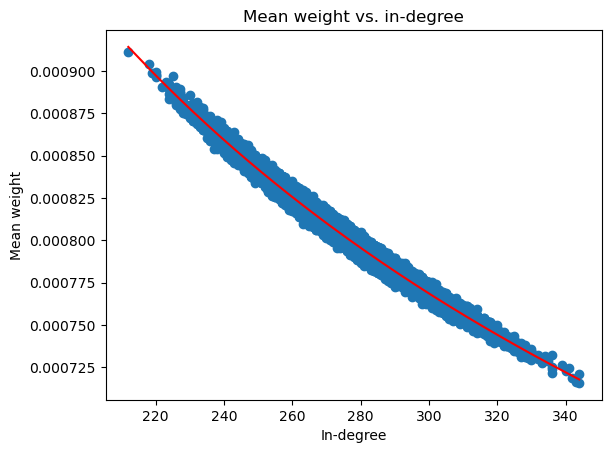

E2E in-degree: 276.7 (mean), 277.1 (gaussian expected)
E2I in-degree: 389.4 (mean), 389.0 (gaussian expected)
I2E in-degree: 222.3 (mean), 222.3 (gaussian expected)
I2I in-degree: 316.7 (mean), 316.8 (gaussian expected)
External in-degree (Exc.): 25.0 (mean)
External in-degree (Inh.): 25.0 (mean)


In [7]:
def mean_weights(proj):
    """
    Calculate the mean input weight for each postsynaptic neuron.
    That is, for each post-syn index i, we compute:
        mean_weights[i] = (sum of weights of all edges leading to i) / (number of edges leading to i).
    """
    # Number of post-synaptic neurons
    M = jnp.prod(jnp.array(proj.post.size))

    # 'indices' is a 1D array listing which post-syn neuron each edge connects to
    indices = jnp.array(proj.comm.indices)
    # 'weight' holds the corresponding weight for each edge in the same order
    weights = jnp.array(proj.comm.weight)

    # 1) in-degree count: how many edges lead to each post-syn i
    in_degs = jnp.bincount(indices, length=M)

    # 2) sum of weights leading to each post-syn i
    sum_w = jnp.bincount(indices, weights=weights, length=M)

    # 3) safely divide sum_w[i] by in_degs[i], handling the case in_degs[i] = 0
    mean_w = jnp.where(in_degs > 0, sum_w / in_degs, 0.0)
    return mean_w
mean_ws = mean_weights(FNSnet.E2E.proj)
ks = src.models.FNS.indegrees(FNSnet.E2E.proj)
plt.scatter(ks, mean_ws)
a, b = np.polyfit(1/np.sqrt(ks), mean_ws, 1)
sks = np.sort(ks)
plt.plot(sks, a/np.sqrt(sks) + b, 'r')
plt.xlabel('In-degree')
plt.ylabel('Mean weight')
plt.title('Mean weight vs. in-degree')
plt.show()


k = src.models.FNS.indegree(FNSnet.E2E.proj)
k_hat = src.models.FNS.expected_indegree(FNSnet, "ee")
print(f"E2E in-degree: {k:.1f} (mean), {k_hat:.1f} (gaussian expected)")
k = src.models.FNS.indegree(FNSnet.E2I.proj)
k_hat = src.models.FNS.expected_indegree(FNSnet, "ei")
print(f"E2I in-degree: {k:.1f} (mean), {k_hat:.1f} (gaussian expected)")
k = src.models.FNS.indegree(FNSnet.I2E.proj)
k_hat = src.models.FNS.expected_indegree(FNSnet, "ie")
print(f"I2E in-degree: {k:.1f} (mean), {k_hat:.1f} (gaussian expected)")
k = src.models.FNS.indegree(FNSnet.I2I.proj)
k_hat = src.models.FNS.expected_indegree(FNSnet, "ii")
print(f"I2I in-degree: {k:.1f} (mean), {k_hat:.1f} (gaussian expected)")

# Print the mean number of external synapses
k_ext = src.models.FNS.indegree(FNSnet.ext2E.proj)
print(f"External in-degree (Exc.): {k_ext:.1f} (mean)")
k_ext = src.models.FNS.indegree(FNSnet.ext2I.proj)
print(f"External in-degree (Inh.): {k_ext:.1f} (mean)")

In [14]:
FNSnet.reinit_weights(85)
FNSnet.reinit_nu(130)
bp.reset_state(FNSnet) # Resets all things recursively, unlike FNSnet.reset_state()

# * No per-neuron balance
# ! xx No common-neighbour property
# ! xx No reverse pooling or lognormal coupling weights

# * Simulate
I = np.array(FNSnet.E.V.value)
I[:] = 0.0
i = I.reshape(*FNSnet.E.size)
i[0:25, 0:25] = 0.0

runner = bp.DSRunner(FNSnet, monitors=['E.V', 'I.V', 'E.spike', 'I.spike', 'E.g_K', 'I.g_K'])# , inputs = [('Ein.input', I)])
runner.run(duration=5000.)

# t = runner.mon['ts'].view()
# X = runner.mon['E.spike'].view()

  0%|          | 0/50000 [00:00<?, ?it/s]

Predict 50000 steps: : 100%|██████████| 50000/50000 [00:57<00:00, 863.89it/s]


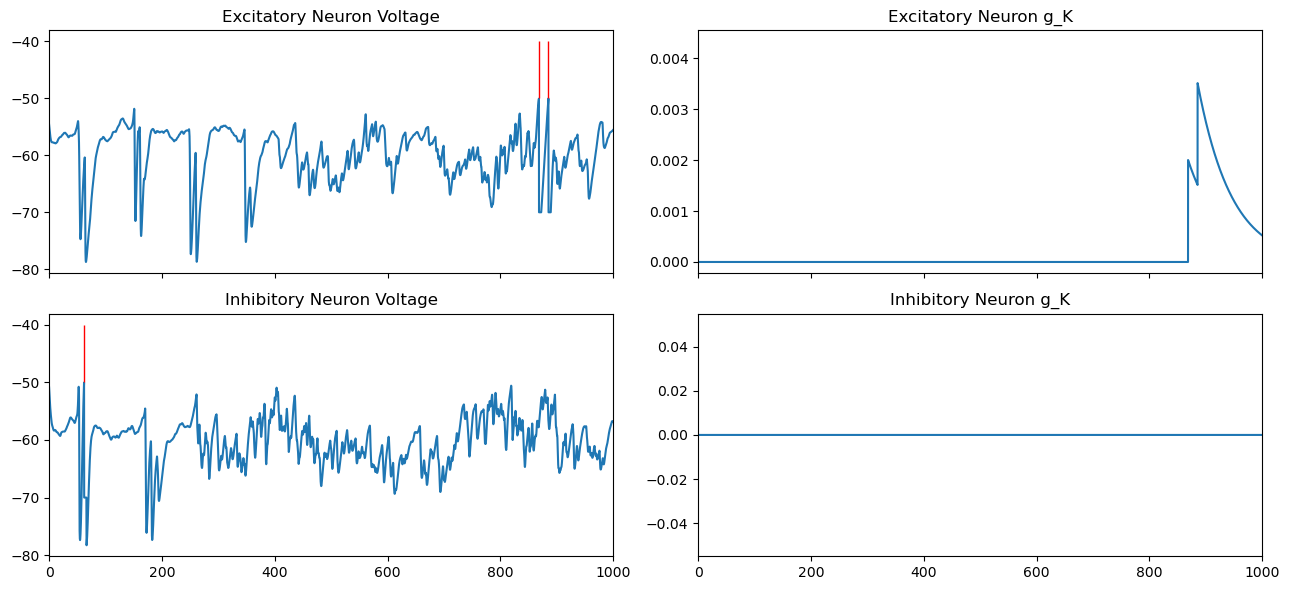

In [15]:
i = 10
fig, axs = plt.subplots(2, 2, figsize=(13, 6), sharex=True)
x = runner.mon['E.V'].view()[:, i]
spikes = np.where(runner.mon['E.spike'].view()[:, i])
axs[0, 0].plot(runner.mon['ts'].view(), x)
spike_times = runner.mon['ts'][spikes]
axs[0, 0].vlines(spike_times, FNSnet.E.V_th, FNSnet.E.V_th + 10,
                  color='r', linewidth=1)
axs[0, 0].set_title('Excitatory Neuron Voltage')
x = runner.mon['I.V'].view()[:, i]
spikes = np.where(runner.mon['I.spike'].view()[:, i])
axs[1, 0].plot(runner.mon['ts'].view(), x)
spike_times = runner.mon['ts'][spikes]
axs[1, 0].vlines(spike_times, FNSnet.E.V_th, FNSnet.E.V_th + 10,
                  color='r', linewidth=1)
axs[1, 0].set_title('Inhibitory Neuron Voltage')

x = runner.mon['E.g_K'].view()[:, i]
axs[0, 1].plot(runner.mon['ts'].view(), x)
axs[0, 1].set_title('Excitatory Neuron g_K')

x = runner.mon['I.g_K'].view()[:, i]
axs[1, 1].plot(runner.mon['ts'].view(), x)
axs[1, 1].set_title('Inhibitory Neuron g_K')


plt.xlim(0, 1000)
plt.tight_layout()
plt.show()

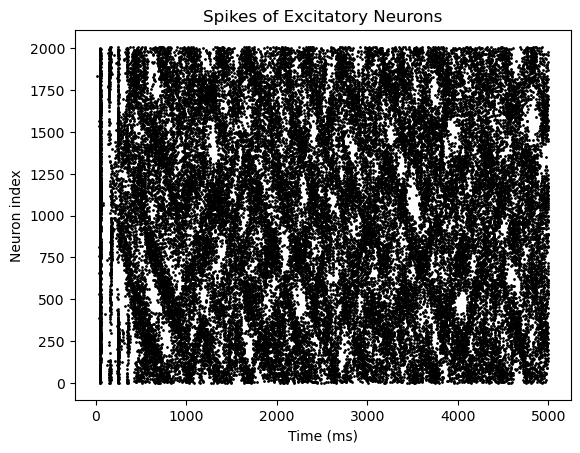

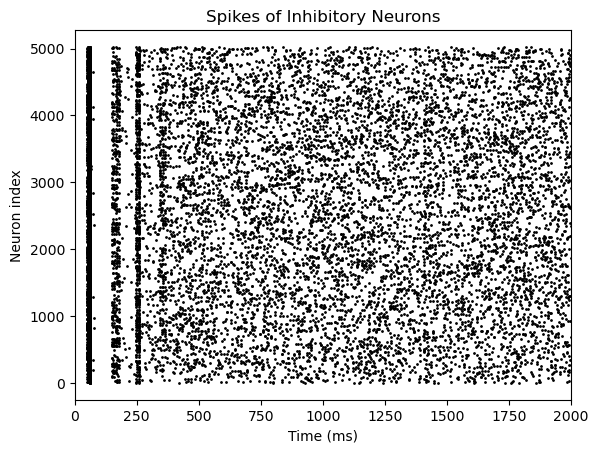

In [17]:
bp.visualize.raster_plot(runner.mon["ts"], runner.mon["E.spike"][:, ::50],
                            title="Spikes of Excitatory Neurons")
plt.show()
bp.visualize.raster_plot(runner.mon["ts"], runner.mon["I.spike"][:, ::5],
                           title="Spikes of Inhibitory Neurons",
                           xlim=(0, 2000))

In [18]:
# bp.visualize.raster_plot(t, X, title='Spikes of Excitatory Neurons', show=True)
%matplotlib inline
from src.plots import animate_spiking_activity
from IPython.display import HTML
ani = animate_spiking_activity(FNSnet, runner, ms_per_s=100, fps=12, window_size_ms=50, tstart=1000)

ani.save("spiking_activity.mp4", writer="ffmpeg")
# HTML(ani.to_jshtml())


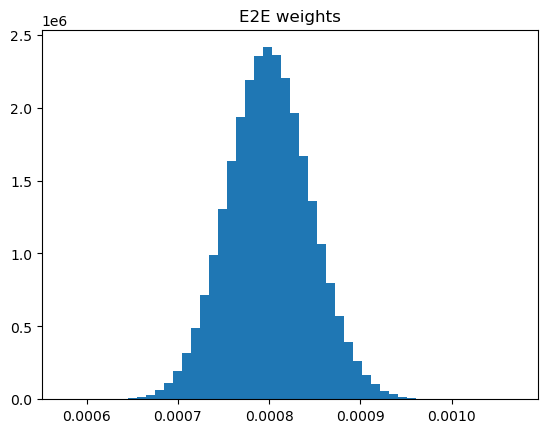

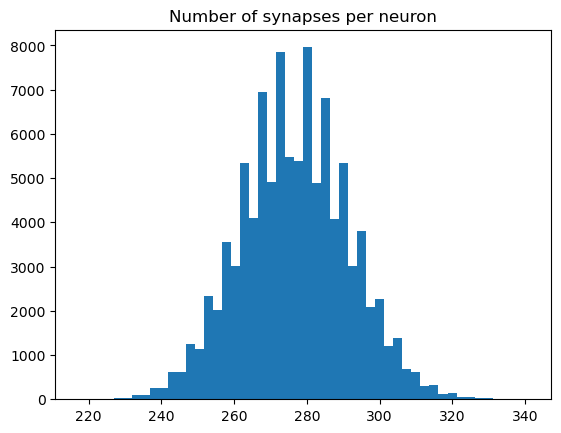

In [12]:
# * First, plot the current distribution of synaptic weights
ws = FNSnet.E2E.proj.comm.weight
plt.hist(ws, bins=50)
plt.gca().set_title('E2E weights')

# * And the number of synapses per neuron
plt.figure()
plt.hist(np.diff(FNSnet.E2E.proj.comm.indptr), bins=50) # ! Check !!!
plt.gca().set_title('Number of synapses per neuron')
plt.show()

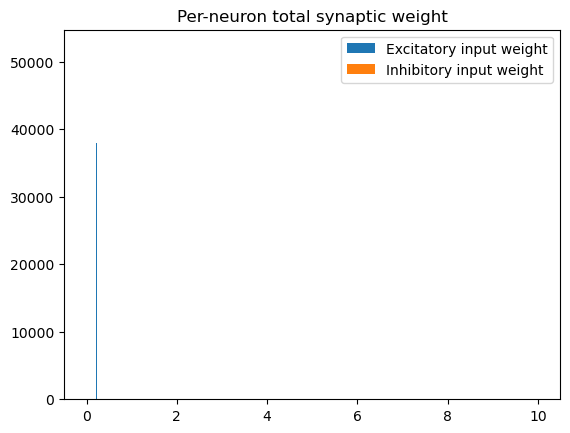

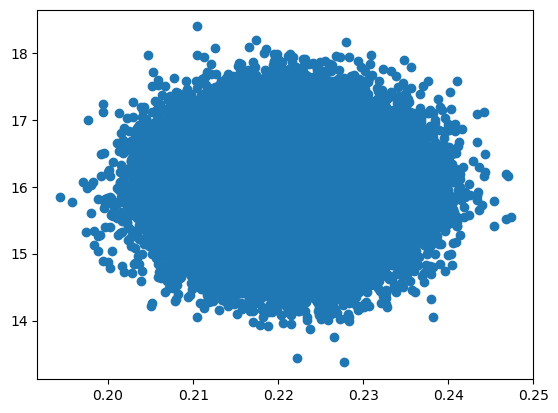

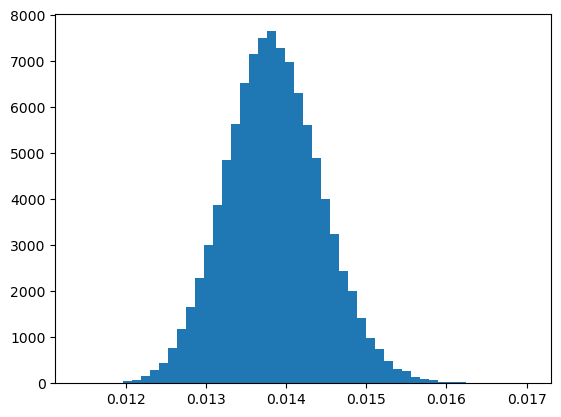

In [13]:
# * Calculate the per-neuron EI balance
# DONT USE REQUIRES, SINCE THAT REBUILDS THE ARRAY
# ? How to peroperly check the balance of weights?
I2E = bp.connect.csr2coo((FNSnet.I2E.proj.comm.indices, FNSnet.I2E.proj.comm.indptr))
E2E = bp.connect.csr2coo((FNSnet.E2E.proj.comm.indices, FNSnet.E2E.proj.comm.indptr))
w_I2E = FNSnet.I2E.proj.comm.weight
w_E2E = FNSnet.E2E.proj.comm.weight
assert len(I2E[0]) == len(w_I2E)

Ne = np.prod(FNSnet.E.size)
sum_exc = np.bincount(E2E[1], weights=w_E2E, minlength=Ne)
sum_inh = np.bincount(I2E[1], weights=w_I2E, minlength=Ne)
bins = np.arange(0, 10, 0.01)
plt.hist(sum_exc, bins=bins, label="Excitatory input weight")
plt.hist(sum_inh, bins=bins, label="Inhibitory input weight")
plt.legend()
plt.title("Per-neuron total synaptic weight")
plt.show()

plt.scatter(sum_exc, sum_inh)
plt.show()

plt.hist(sum_exc/sum_inh, bins=50)
plt.show()
